# 9. Paper 1 model tables and plots

Assemble publication outputs for the stacked conditional-logit model and the XGBoost/neural winners frozen in Stage 8. Stage 9 validates the SHA-256 hashes of the development-CV summary, experiment plan, and frozen ranking before it opens any held-out artifact. It never reselects a model from held-out performance.

Primary outputs use `all`. Set `COMMENTGAP_MODEL_SCOPES=all,root` to add matching appendix tables. The reporter refuses to run while the factorial launcher is active.

In [1]:
from pathlib import Path
import json
import os

import pandas as pd
from IPython.display import display
from commentgap_analysis.explanations import summarize_shap_story_variability, summarize_shap_values

from commentgap_analysis.paper1_reporting import run_paper1_reporting
from commentgap_analysis.paper1_plotting import (
    plot_regression_selector_coefficients,
    plot_regression_selector_differences,
    plot_regression_vs_shap_gaps,
    plot_winner_permutation_importance,
    plot_winner_permutation_importance_gaps,
    plot_winner_shap_importance,
    plot_winner_shap_importance_gaps,
)

scope_text = os.getenv("COMMENTGAP_MODEL_SCOPES", "all")
SCOPES = tuple(dict.fromkeys(part.strip() for part in scope_text.split(",") if part.strip()))
if not SCOPES or not set(SCOPES).issubset({"all", "root"}):
    raise ValueError(f"Invalid COMMENTGAP_MODEL_SCOPES={scope_text!r}")
MODEL_DATA_ROOT = Path(os.getenv("COMMENTGAP_MODEL_DATA_ROOT", "model_output/selection_2025/model_data"))
FACTORIAL_ROOT = Path(os.getenv("COMMENTGAP_FACTORIAL_ROOT", "model_output/selection_2025/factorial_rankers"))
WINNER_ROOT = Path(os.getenv("COMMENTGAP_FACTORIAL_WINNER_ROOT", "model_output/selection_2025/paper1/factorial_winners"))
REGRESSION_ROOT = Path(os.getenv("COMMENTGAP_REGRESSION_ROOT", "model_output/selection_2025/regression"))
OUTPUT_ROOT = Path(os.getenv("COMMENTGAP_REPORT_ROOT", "model_output/selection_2025/paper1/reporting"))
TABLES = OUTPUT_ROOT / "tables"
PERMUTATION_REPEATS = int(os.getenv("COMMENTGAP_PERMUTATION_REPEATS", "1"))
SHAP_TEST_ROWS = int(os.getenv("COMMENTGAP_SHAP_TEST_ROWS", "50000"))
SHAP_BACKGROUND_ROWS = int(os.getenv("COMMENTGAP_SHAP_BACKGROUND_ROWS", "2048"))
SHAP_NSAMPLES = int(os.getenv("COMMENTGAP_SHAP_NSAMPLES", "100"))
SHAP_FORCE_RECOMPUTE = os.getenv("COMMENTGAP_SHAP_FORCE_RECOMPUTE", "0") == "1"
SHAP_CHUNK_ROWS = int(os.getenv("COMMENTGAP_SHAP_CHUNK_ROWS", "500"))
{"scopes": SCOPES, "winner_manifest": str(WINNER_ROOT / "factorial_winner_manifest.json"), "output": str(OUTPUT_ROOT)}

{'scopes': ('all',),
 'winner_manifest': 'model_output/selection_2025/paper1/factorial_winners/factorial_winner_manifest.json',
 'output': 'model_output/selection_2025/paper1/reporting'}

In [2]:
report_manifest = run_paper1_reporting(
    model_data_root=MODEL_DATA_ROOT,
    factorial_root=FACTORIAL_ROOT,
    winner_root=WINNER_ROOT,
    regression_root=REGRESSION_ROOT,
    output_root=OUTPUT_ROOT,
    scopes=SCOPES,
    bootstrap_draws=1000,
    permutation_repeats=PERMUTATION_REPEATS,
    shap_test_rows=SHAP_TEST_ROWS,
    shap_background_rows=SHAP_BACKGROUND_ROWS,
    shap_nsamples=SHAP_NSAMPLES,
    shap_force_recompute=SHAP_FORCE_RECOMPUTE,
    shap_chunk_rows=SHAP_CHUNK_ROWS,
    make_figures=True,
    make_latex_tables=False,
)
report_manifest

[SHAP] winner 1/4: neural nn__metadata_bge__draw1__random4__plateau__separate__base all
[SHAP] reused cache: neural nn__metadata_bge__draw1__random4__plateau__separate__base all
[SHAP] winner 2/4: neural nn__metadata__draw1__random4__plateau__separate__base all
[SHAP] reused cache: neural nn__metadata__draw1__random4__plateau__separate__base all
[SHAP] winner 3/4: xgboost xgb__metadata_bge__draw1 all
[SHAP] reused cache: xgboost xgb__metadata_bge__draw1 all
[SHAP] winner 4/4: xgboost xgb__metadata__draw1 all
[SHAP] reused cache: xgboost xgb__metadata__draw1 all


{'version': 3,
 'created_at': '2026-09-15T09:45:10.961043+00:00',
 'scopes': ['all'],
 'primary_scope': 'all',
 'appendix_scope': 'root',
 'winner_selection': 'development CV only; held-out artifacts opened only after winner-manifest hash validation',
 'winner_manifest': {'path': 'model_output/selection_2025/paper1/factorial_winners/factorial_winner_manifest.json',
  'sha256': '793592508db1f0cae3604046a4726996bd0bd331baabb197773dd48b9ae23cc7'},
 'development_cv_sha256': '8a4a3cf02c124d3d78363a2b32071efa87c44779113267526761a81ef80aed68',
 'bootstrap_draws': 1000,
 'balanced_f1_draws': 100,
 'permutation_repeats': 1,
 'model_implied_gap': 'predicted curator top-k ranked by predicted audience score; midranks and fractional curator cutoff ties; equal-article mean, candidate-comment-weighted mean, and candidate-comment-weighted median are reported',
 'comment_weighting': 'sum(n_candidates * article_gap) / sum(n_candidates); confidence interval resamples articles and recomputes the weighted 

In [3]:
# The report writer uses a non-interactive backend while saving files.
# Restore an inline backend before displaying figures in VS Code.
%matplotlib inline

## Selector feature gaps

This section compares three complementary views of feature use: stacked-model coefficients, held-out permutation importance, and SHAP attribution. The regression feature gap is the signed curator-minus-audience interaction on the log-odds scale. XGBoost and neural feature gaps are paired within-article permutation losses: curator nDCG@k importance minus audience nDCG@k importance. SHAP plots use signed mean attribution and signed editor-minus-audience gaps. Positive values indicate an upward contribution or greater editor-specific contribution; negative values indicate a downward contribution or greater audience-specific contribution. Audience importance averages the ten deterministic tie draws. Permutations cover the named tabular features; frozen BGE vectors remain fixed rather than treating their 1,024 latent dimensions as separate substantive features.

,term,feature,unit,audience_log_odds,audience_se,audience_conf_low,audience_conf_high,audience_odds_ratio,audience_p_value,curator_log_odds,...,difference_conf_high,difference_p_value,audience_q_value_bh,curator_q_value_bh,difference_q_value_bh,scope,feature_gap_log_odds,feature_gap_conf_low,feature_gap_conf_high,curator_to_audience_odds_ratio
0,log_words,Comment length (log words),One standard deviation,0.454184,0.040239,0.375317,0.533052,1.574888,1.519403e-29,0.590024,...,0.200545,3.877261e-05,1.038258e-28,4.422450e-46,1.222829e-04,all,0.135839,0.071134,0.200545,1.145498
1,sentiment_positive,Positive sentiment,One standard deviation,0.075451,0.016021,0.044050,0.106851,1.078370,2.482925e-06,0.107621,...,0.059145,1.941902e-02,5.089997e-06,9.120524e-11,2.843499e-02,all,0.032170,0.005195,0.059145,1.032693
2,sentiment_negative,Negative sentiment,One standard deviation,0.082010,0.017704,0.047311,0.116709,1.085467,3.615858e-06,0.026407,...,-0.025841,2.504485e-04,6.738644e-06,1.700106e-01,6.417743e-04,all,-0.055603,-0.085364,-0.025841,0.945915
3,toxicity_probability,Maximum toxicity probability,One standard deviation,-0.024980,0.011168,-0.046869,-0.003091,0.975330,2.530539e-02,-0.133283,...,-0.089838,1.390563e-30,3.458404e-02,3.063602e-28,2.850653e-29,all,-0.108303,-0.126769,-0.089838,0.897355
4,lexdiv_length_adjusted,Length-adjusted lexical diversity,One standard deviation,-0.017050,0.008375,-0.033464,-0.000635,0.983095,4.176739e-02,0.005828,...,0.036113,7.040012e-04,5.036656e-02,4.898703e-01,1.374478e-03,all,0.022878,0.009643,0.036113,1.023142
5,reading_level_length_adjusted,Length-adjusted reading difficulty,One standard deviation,0.074005,0.010974,0.052496,0.095513,1.076812,1.543355e-11,0.042246,...,-0.014141,4.106308e-04,4.867505e-11,1.695843e-04,9.353256e-04,all,-0.031759,-0.049376,-0.014141,0.968740
6,url_present,URL present,Absent to present,-0.615738,0.089183,-0.790534,-0.440943,0.540242,5.048020e-12,0.428235,...,1.196352,4.137284e-41,1.724740e-11,9.120524e-11,1.696286e-39,all,1.043974,0.891596,1.196352,2.840482
7,article_similarity_top3,Article similarity (top-three passages),One standard deviation,0.033068,0.015875,0.001953,0.064182,1.033621,3.724953e-02,0.120772,...,0.114443,1.287508e-10,4.627972e-02,4.672835e-14,1.055757e-09,all,0.087704,0.060965,0.114443,1.091665
8,novelty_prior_all_model,Novelty from earlier comments,One standard deviation,-0.123617,0.013156,-0.149403,-0.097832,0.883718,5.649914e-21,-0.085206,...,0.060427,6.270553e-04,3.309235e-20,4.981886e-10,1.285463e-03,all,0.038412,0.016396,0.060427,1.039159
9,log_hours_since_article,Hours since article publication,One standard deviation,-1.540940,0.044703,-1.628557,-1.453323,0.214180,2.235216e-260,-1.207295,...,0.398869,1.173275e-23,9.164386e-259,1.374641e-202,1.603476e-22,all,0.333645,0.268420,0.398869,1.396047


,scope,model_family,model_id,model_label,feature,permutation_importance_gap,conf_low,conf_high,n_articles,bootstrap_draws,audience_importance,curator_importance,permutation_repeats,feature_label
28,all,neural,nn__metadata__draw1__random4__plateau__separat...,Neural winner,log_hours_since_article,-2.142678e-02,-0.031309,-0.012152,2559,1000,0.135488,0.114062,1,Hours since article publication
29,all,neural,nn__metadata__draw1__random4__plateau__separat...,Neural winner,log_words,1.924568e-02,0.011495,0.027340,2559,1000,0.019784,0.039029,1,Comment length (log words)
111,all,xgboost,xgb__metadata__draw1,XGBoost winner,log_words,1.840176e-02,0.012193,0.024813,2559,1000,0.012768,0.031170,1,Comment length (log words)
152,all,xgboost,xgb__metadata_bge__draw1,XGBoost winner,log_words,1.712301e-02,0.011588,0.023015,2559,1000,0.011285,0.028408,1,Comment length (log words)
151,all,xgboost,xgb__metadata_bge__draw1,XGBoost winner,log_hours_since_article,-1.602100e-02,-0.024172,-0.008236,2559,1000,0.130770,0.114749,1,Hours since article publication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,all,neural,nn__metadata_bge__draw1__random4__plateau__sep...,Neural winner,vienna_weekend_day_evening,9.570814e-06,-0.002045,0.002094,2559,1000,0.000856,0.000865,1,Weekend daytime/evening
133,all,xgboost,xgb__metadata_bge__draw1,XGBoost winner,aqua_referencing_medium_expected,-2.888254e-07,-0.000351,0.000346,2559,1000,0.000121,0.000121,1,"AQuA Reference to medium, editor, or moderator..."
161,all,xgboost,xgb__metadata_bge__draw1,XGBoost winner,vienna_overnight,0.000000e+00,0.000000,0.000000,2559,1000,0.000000,0.000000,1,Overnight posting period
162,all,xgboost,xgb__metadata_bge__draw1,XGBoost winner,vienna_weekday_shoulder_evening,0.000000e+00,0.000000,0.000000,2559,1000,0.000000,0.000000,1,Weekday shoulder/evening


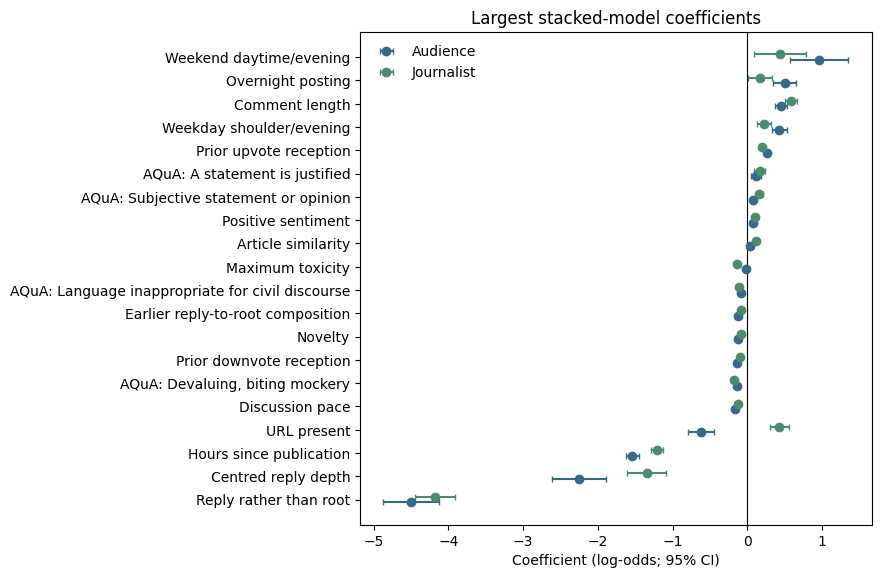

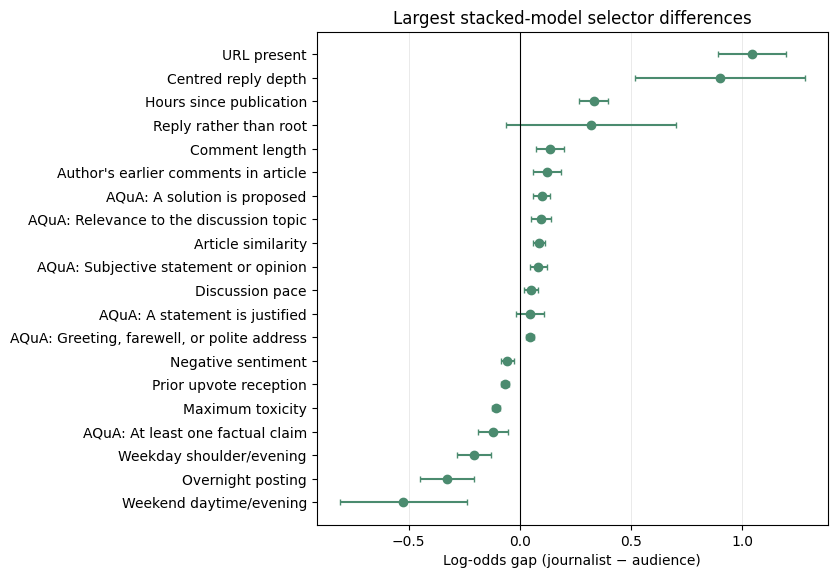

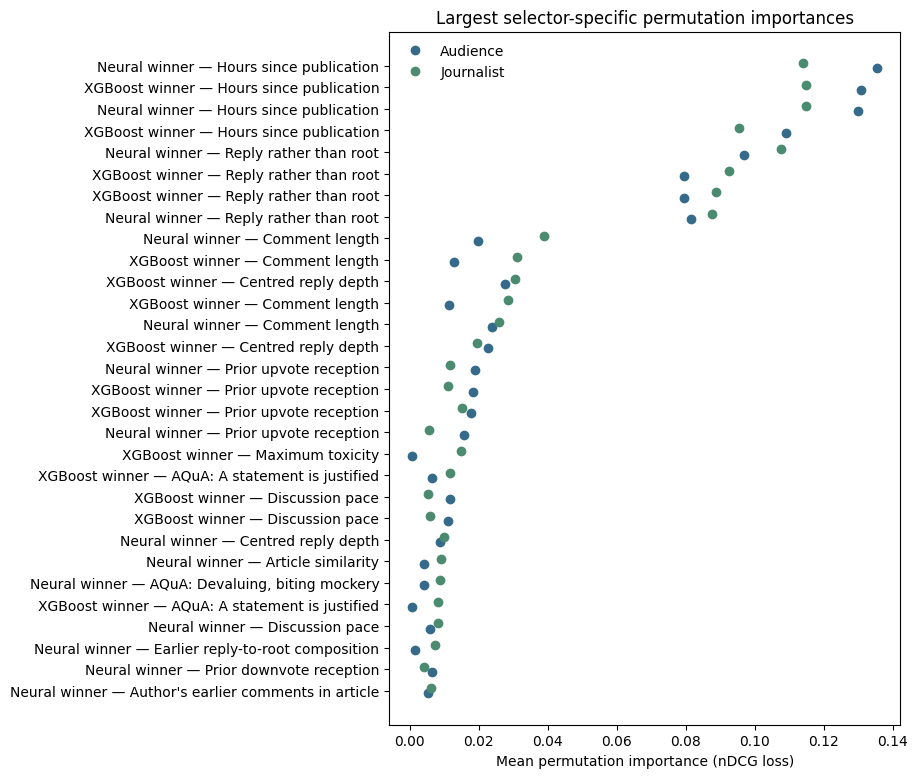

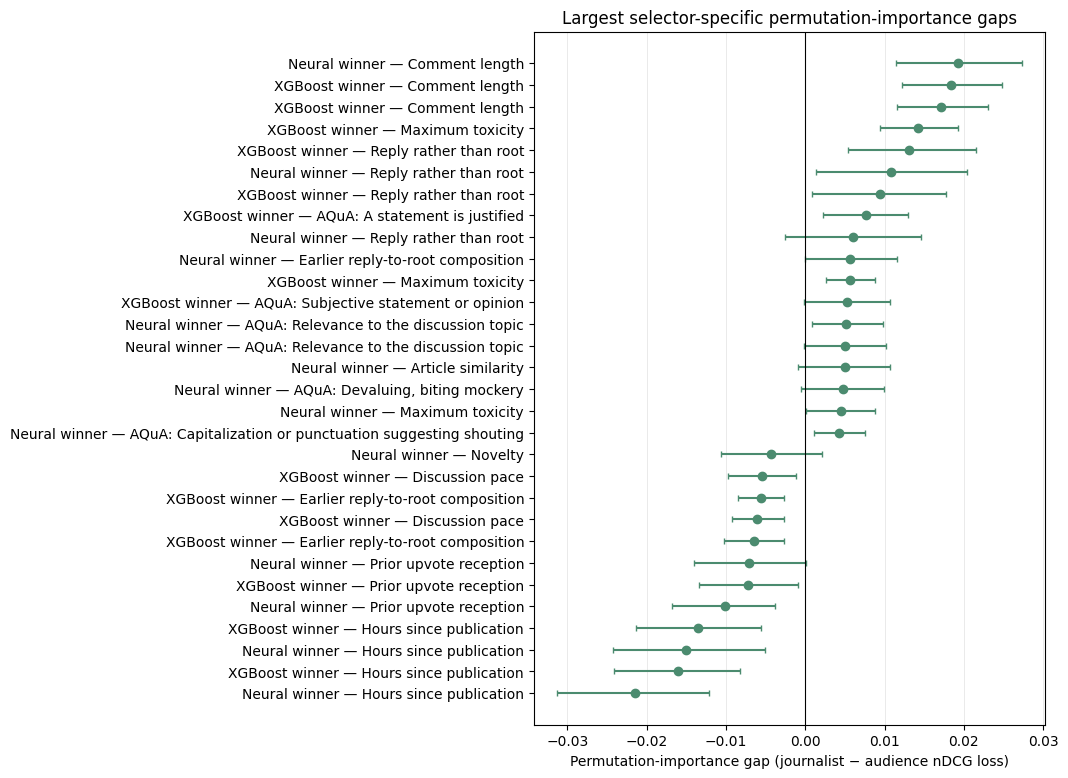

In [4]:
regression_feature_gaps = pd.read_csv(TABLES / "regression_feature_gaps.csv")
permutation_gaps = pd.read_csv(TABLES / "held_out_permutation_importance_gaps.csv")
display(regression_feature_gaps)
display(permutation_gaps.sort_values("permutation_importance_gap", key=abs, ascending=False))
display(plot_regression_selector_coefficients(regression_feature_gaps, output_root=None, show=False))
display(plot_regression_selector_differences(regression_feature_gaps, output_root=None, show=False))
display(plot_winner_permutation_importance(permutation_gaps, output_root=None, show=False))
display(plot_winner_permutation_importance_gaps(permutation_gaps, output_root=None, show=False))

## SHAP artifacts

Stage 9 calculates SHAP for the frozen XGBoost and neural winners on the sealed `paper2_test` comments. The background is development-only; BGE dimensions are summed into the `text_bge` block. The report exports both selector-specific signed mean SHAP contributions and signed editor-minus-audience SHAP gaps; the figures show the story-level interquartile range (IQR) as variability bars, while mean absolute SHAP remains available in the table as an importance diagnostic. Notebook 12 consumes the story-aggregated summary for the FORUM comparison.

,scope,model_family,model_id,feature_set,feature,mean_shap,mean_abs_shap,n_stories,sampled_comments,mean_abs_shap_audience,...,aggregation,mean_shap_audience_story_q25,mean_shap_audience_story_q75,mean_shap_curator_story_q25,mean_shap_curator_story_q75,mean_shap_gap_story_q25,mean_shap_gap_story_q75,story_count,story_lower_quantile,story_upper_quantile
0,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_additional_knowledge_expected,0.035235,0.081584,2559,100000,0.081596,...,"mean over comments within story, then equal me...",0.017514,0.055266,0.013082,0.054555,-0.021846,0.017592,2559.0,0.25,0.75
1,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_discrimination_expected,0.027137,0.150767,2559,100000,0.193139,...,"mean over comments within story, then equal me...",-0.028888,0.101561,-0.009995,0.062820,-0.046287,0.027198,2559.0,0.25,0.75
2,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_fact_expected,0.044820,0.122209,2559,100000,0.113748,...,"mean over comments within story, then equal me...",0.001680,0.078547,0.008557,0.086057,-0.012571,0.025430,2559.0,0.25,0.75
3,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_insult_expected,0.020404,0.145358,2559,100000,0.166350,...,"mean over comments within story, then equal me...",-0.037391,0.057957,-0.007208,0.064434,-0.003670,0.038403,2559.0,0.25,0.75
4,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_justification_expected,0.029358,0.098038,2559,100000,0.073681,...,"mean over comments within story, then equal me...",0.004592,0.042072,-0.000022,0.070526,-0.013756,0.040557,2559.0,0.25,0.75
5,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_opinion_expected,0.023963,0.134853,2559,100000,0.088291,...,"mean over comments within story, then equal me...",-0.004761,0.042143,-0.026197,0.078684,-0.056656,0.067590,2559.0,0.25,0.75
6,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_polite_address_expected,0.003692,0.066740,2559,100000,0.059587,...,"mean over comments within story, then equal me...",-0.024478,0.013932,-0.028620,0.017078,-0.010644,0.011654,2559.0,0.25,0.75
7,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_question_expected,0.039711,0.122142,2559,100000,0.108901,...,"mean over comments within story, then equal me...",0.016677,0.064307,0.016487,0.077952,-0.012780,0.025679,2559.0,0.25,0.75
8,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_referencing_contents_expected,-0.010252,0.107449,2559,100000,0.104532,...,"mean over comments within story, then equal me...",-0.039239,0.019012,-0.037093,0.026538,-0.008621,0.017929,2559.0,0.25,0.75
9,all,neural,nn__metadata__draw1__random4__plateau__separat...,metadata,aqua_referencing_format_expected,0.022663,0.132259,2559,100000,0.092682,...,"mean over comments within story, then equal me...",-0.009631,0.044386,-0.034303,0.071042,-0.027485,0.029684,2559.0,0.25,0.75


168 story-aggregated SHAP rows


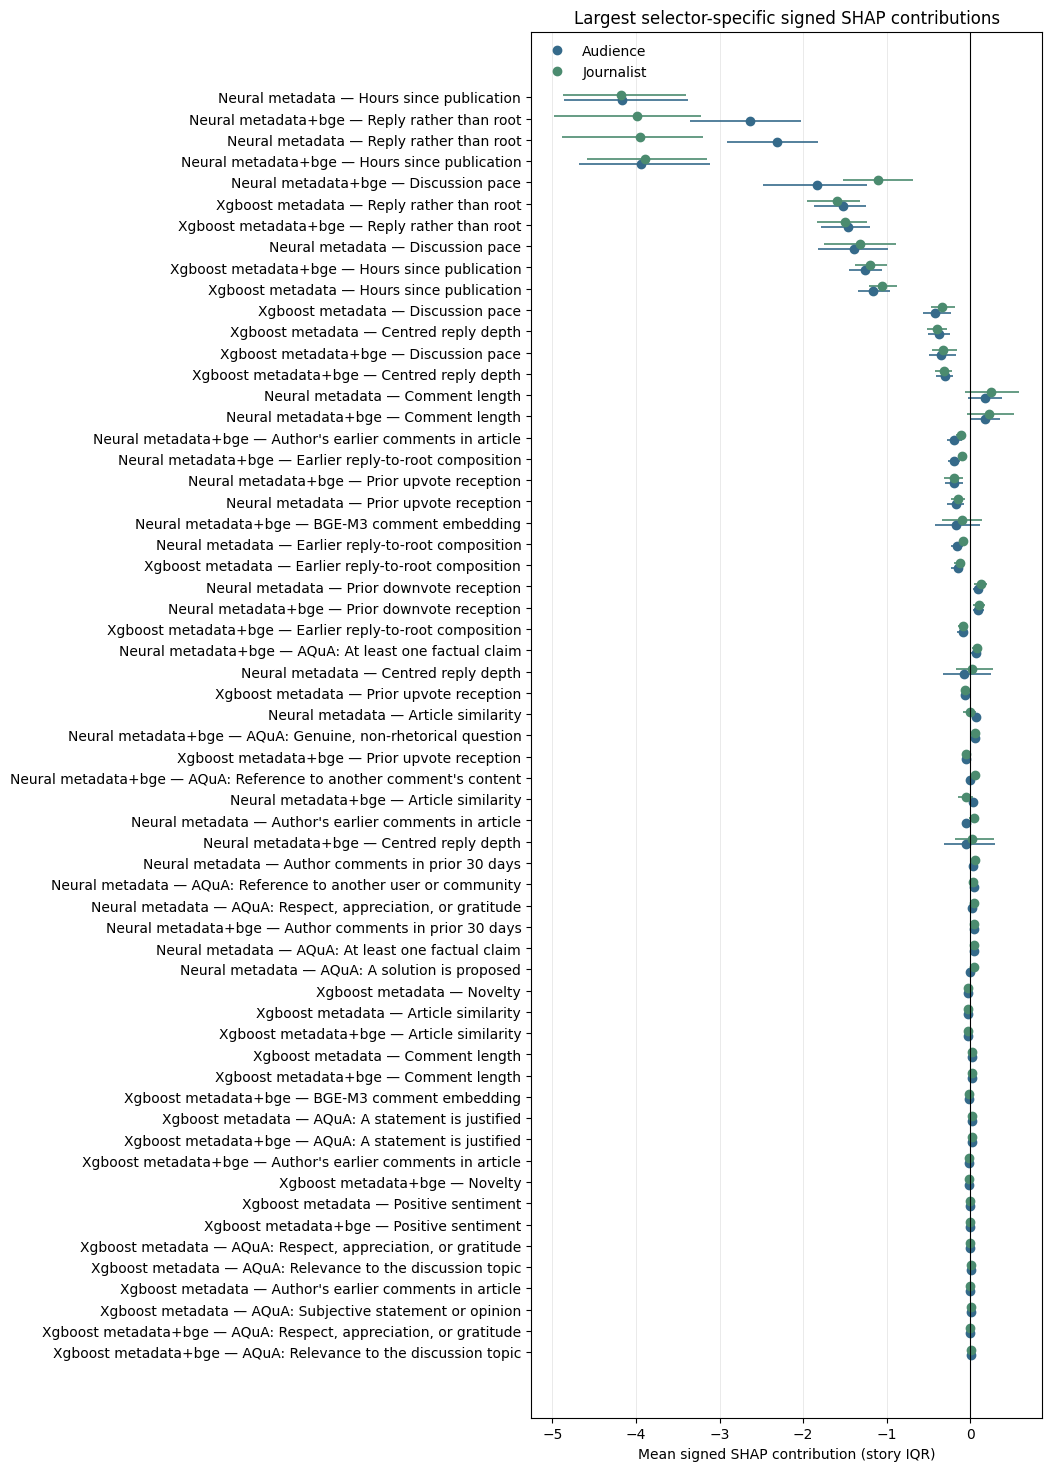

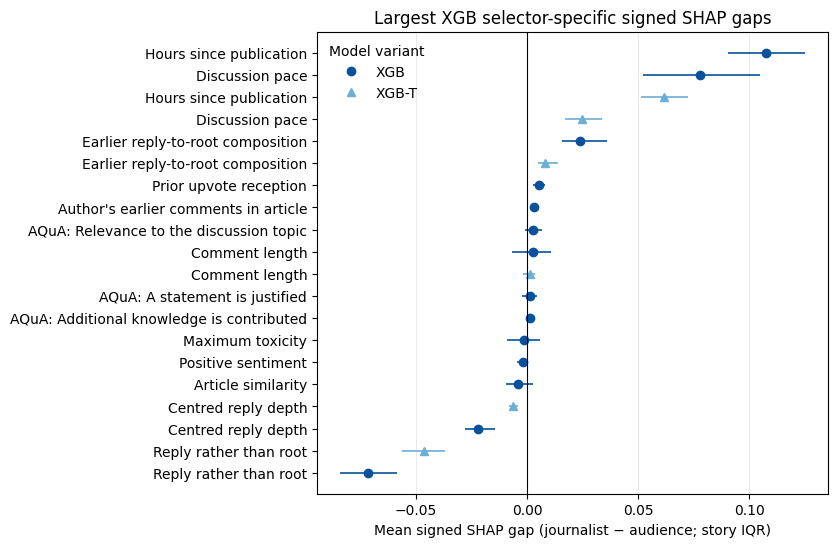

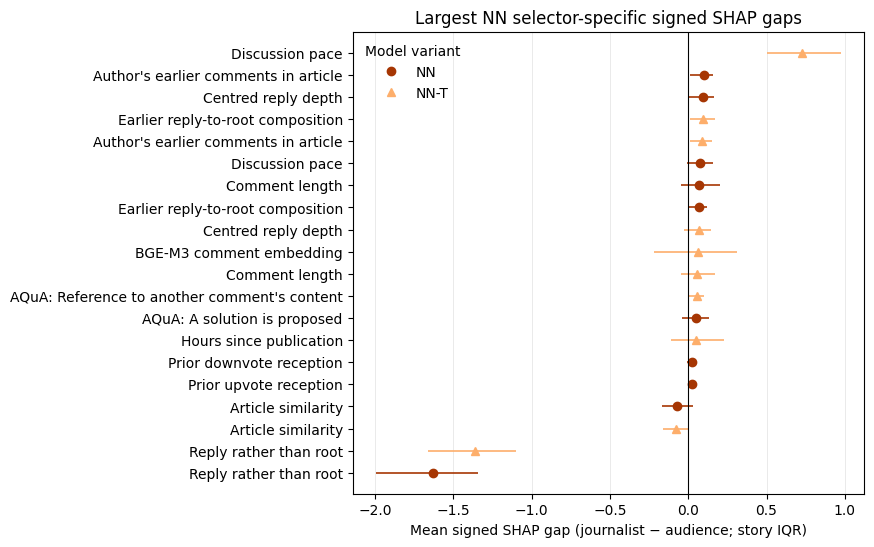

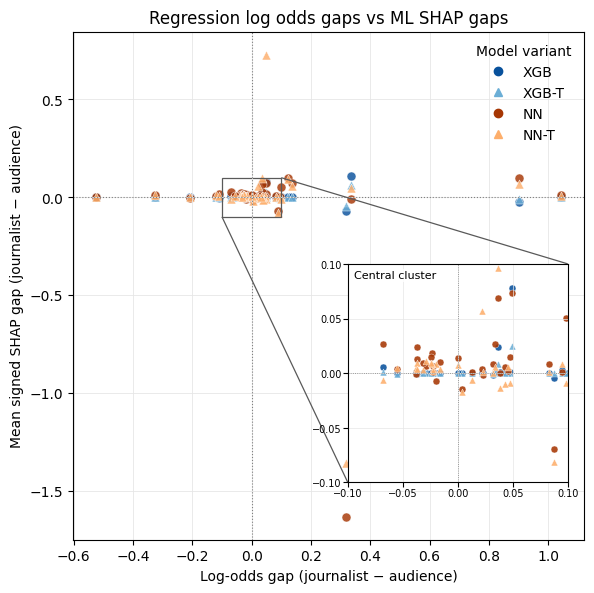

In [5]:
shap_values = pd.read_parquet(TABLES / "held_out_shap_values.parquet")
shap_summary = summarize_shap_values(shap_values)
shap_story_variability = summarize_shap_story_variability(shap_values)
shap_summary = shap_summary.merge(
    shap_story_variability,
    on=["scope", "model_family", "model_id", "feature_set", "feature"],
    how="left", validate="one_to_one",
)
shap_summary.to_parquet(TABLES / "held_out_shap_importance.parquet", index=False)
shap_summary.to_csv(TABLES / "held_out_shap_importance.csv", index=False)
shap_story_variability.to_parquet(TABLES / "held_out_shap_story_variability.parquet", index=False)
display(shap_summary.head(20))
print(f"{len(shap_summary):,} story-aggregated SHAP rows")
display(plot_winner_shap_importance(shap_summary, output_root=OUTPUT_ROOT, show=False))
for shap_gap_figure in plot_winner_shap_importance_gaps(shap_summary, output_root=OUTPUT_ROOT, show=False, limit=40):
    display(shap_gap_figure)
display(plot_regression_vs_shap_gaps(regression_feature_gaps, shap_summary, output_root=OUTPUT_ROOT, show=False))

## Frozen winners and development CV

In [5]:
TABLES = OUTPUT_ROOT / "tables"
winners = pd.read_csv(TABLES / "development_cv_winners.csv")
cv_ranking = pd.read_csv(TABLES / "development_cv_variant_ranking.csv")
display(winners)
display(cv_ranking.groupby(["family", "scope"], group_keys=False).head(10))

,completed_folds,development_cv_rank,draw_policy,family,feature_set,heads,mean_audience_ndcg_at_k,mean_curator_ndcg_at_k,mean_macro_ndcg_at_k,min_fold_macro_ndcg_at_k,negative_sampling,network,schedule,scope,sd_macro_ndcg_at_k,variant_id
0,5,1,draw1,neural,metadata_bge,separate,NaN,NaN,0.239345,0.231591,random4,base,plateau,all,0.006855,nn__metadata_bge__draw1__random4__plateau__sep...
1,5,1,draw1,neural,metadata,separate,NaN,NaN,0.234001,0.227537,random4,base,plateau,all,0.003999,nn__metadata__draw1__random4__plateau__separat...
2,5,1,draw1,xgboost,metadata_bge,na,0.243889,0.259445,0.251667,0.242912,na,na,na,all,0.007819,xgb__metadata_bge__draw1
3,5,1,draw1,xgboost,metadata,na,0.234949,0.254954,0.244951,0.239520,na,na,na,all,0.005827,xgb__metadata__draw1


,variant_id,family,scope,mean_macro_ndcg_at_k,sd_macro_ndcg_at_k,min_fold_macro_ndcg_at_k,completed_folds,mean_audience_ndcg_at_k,mean_curator_ndcg_at_k,feature_set,draw_policy,negative_sampling,schedule,heads,network,development_cv_rank
0,nn__metadata_bge__draw1__random4__plateau__sep...,neural,all,0.239345,0.006855,0.231591,5,NaN,NaN,metadata_bge,draw1,random4,plateau,separate,base,1
1,nn__metadata_bge__draw1__random4__plateau__sep...,neural,all,0.234915,0.007120,0.226386,5,NaN,NaN,metadata_bge,draw1,random4,plateau,separate,large,2
2,nn__metadata_bge__draw1__random4__plateau__sha...,neural,all,0.234231,0.007280,0.227057,5,NaN,NaN,metadata_bge,draw1,random4,plateau,shared_residual,base,3
3,nn__metadata__draw1__random4__plateau__separat...,neural,all,0.234001,0.003999,0.227537,5,NaN,NaN,metadata,draw1,random4,plateau,separate,base,1
4,nn__metadata_bge__draw1__random4__plateau__sha...,neural,all,0.233262,0.007378,0.223426,5,NaN,NaN,metadata_bge,draw1,random4,plateau,shared_residual,large,4
5,nn__metadata__draw1__random4__plateau__shared_...,neural,all,0.232512,0.004032,0.228347,5,NaN,NaN,metadata,draw1,random4,plateau,shared_residual,base,2
6,nn__metadata__draw1__random4__plateau__separat...,neural,all,0.229178,0.008540,0.216387,5,NaN,NaN,metadata,draw1,random4,plateau,separate,large,3
7,nn__metadata_bge__draw1__random4__fixed__separ...,neural,all,0.225028,0.011107,0.213183,5,NaN,NaN,metadata_bge,draw1,random4,fixed,separate,base,5
8,nn__metadata__draw1__random4__plateau__shared_...,neural,all,0.224671,0.008077,0.213680,5,NaN,NaN,metadata,draw1,random4,plateau,shared_residual,large,4
9,nn__metadata_bge__draw1__random4__fixed__separ...,neural,all,0.224493,0.009544,0.214410,5,NaN,NaN,metadata_bge,draw1,random4,fixed,separate,large,6


## Development and held-out results

The first table is in-sample development performance from the frozen models fitted on all development articles; it has the same audience/editor nDCG and balanced macro-F1 columns as the sealed test table. These values are descriptive training-set diagnostics, not estimates of generalisation. The separate development-CV table above remains the model-selection result. The second table is the sealed `paper2_test` evaluation and is the source of Figure 26.

These results are opened only after winner freezing. Paired differences are clustered by held-out article and use the second-minus-first direction named in `comparison`. For `mean_selected_rank`, lower values are better; the other reported ranking metrics are better when higher. The balanced macro-F1 table is a secondary paper-comparison diagnostic: non-selected comments are undersampled within each article-selector query, the top k scores are selected, and macro-F1 is averaged over articles.

In [6]:
import numpy as np

from commentgap_analysis.neural_ranking import scores_to_long
from commentgap_analysis.paper1_reporting import (
    _bootstrap_group_mean,
    _selector_article_ndcg,
    bold_best_latex,
    balanced_macro_f1_at_k,
    performance_ci,
    score_development_model,
    training_ci,
)

development = pd.read_csv(TABLES / "development_cv_winners.csv")
performance = pd.read_csv(TABLES / "held_out_model_performance.csv")
paired = pd.read_csv(TABLES / "held_out_paired_model_differences.csv")
balanced_f1 = pd.read_csv(TABLES / "held_out_balanced_macro_f1.csv")
balanced_f1_paired_path = TABLES / "held_out_paired_balanced_macro_f1.csv"
balanced_f1_paired = pd.read_csv(balanced_f1_paired_path) if balanced_f1_paired_path.exists() else pd.DataFrame()

model_order = {"Reg": 0, "XGB": 1, "XGB-T": 2, "NN": 3, "NN-T": 4}
development_labels = {
    ("xgboost", "metadata"): "XGB",
    ("xgboost", "metadata_bge"): "XGB-T",
    ("neural", "metadata"): "NN",
    ("neural", "metadata_bge"): "NN-T",
}
development = development[development["scope"].eq("all")].copy()
development["Model"] = [
    development_labels.get((family, feature_set))
    for family, feature_set in zip(development["family"], development["feature_set"])
]
winner_records = {
    str(row["variant_id"]): row.to_dict()
    for _, row in development.loc[development["scope"].eq("all")].iterrows()
}
training_article_frames = []
for index, label in enumerate(("Reg", "XGB", "XGB-T", "NN", "NN-T")):
    if label == "Reg":
        wide = score_development_model(
            model_family="conditional_logit",
            model_data_root=MODEL_DATA_ROOT,
            factorial_root=FACTORIAL_ROOT,
            regression_root=REGRESSION_ROOT,
            scope="all",
        )
    else:
        winner = next(
            record for record in winner_records.values()
            if development_labels.get((record["family"], record["feature_set"])) == label
        )
        wide = score_development_model(
            model_family=str(winner["family"]),
            model_data_root=MODEL_DATA_ROOT,
            factorial_root=FACTORIAL_ROOT,
            regression_root=REGRESSION_ROOT,
            winner=winner,
            scope="all",
        )
    ndcg_articles = _selector_article_ndcg(wide)
    f1_articles = balanced_macro_f1_at_k(
        scores_to_long(wide, audience_draw=1),
        draws=100,
        seed=20260813 + index * 100_000,
    )
    article = ndcg_articles.merge(
        f1_articles[["story_id", "selector", "balanced_macro_f1_at_k"]],
        on=["story_id", "selector"],
        validate="one_to_one",
    )
    training_article_frames.append(article.assign(Model=label))

training_articles = pd.concat(training_article_frames, ignore_index=True)
training_metric_frames = []
for metric in ("ndcg_at_k", "balanced_macro_f1_at_k"):
    summary = _bootstrap_group_mean(
        training_articles,
        groups=["Model", "selector"],
        value=metric,
        draws=1000,
        seed=20260813 + (0 if metric == "ndcg_at_k" else 1_000_000),
        estimate_name="estimate",
    )
    summary["metric"] = metric
    training_metric_frames.append(summary)
training_metrics = pd.concat(training_metric_frames, ignore_index=True)

training_table = pd.DataFrame([
    {
        "Model": label,
        "Audience nDCG@k": training_ci(training_metrics, label, "audience", "ndcg_at_k"),
        "Editor nDCG@k": training_ci(training_metrics, label, "curator", "ndcg_at_k"),
        "Audience macro-F1": training_ci(training_metrics, label, "audience", "balanced_macro_f1_at_k"),
        "Editor macro-F1": training_ci(training_metrics, label, "curator", "balanced_macro_f1_at_k"),
    }
    for label in ("Reg", "XGB", "XGB-T", "NN", "NN-T")
])
display(training_table)
training_table.to_csv(TABLES / "figure_26_training_model_performance.csv", index=False)
training_columns = ["Audience nDCG@k", "Editor nDCG@k", "Audience macro-F1", "Editor macro-F1"]
training_latex = bold_best_latex(training_table, training_columns)
training_latex.to_latex(TABLES / "figure_26_training_model_performance.tex", index=False, escape=False)
performance_table = (
    performance.assign(order=performance["model_pair_label"].map(model_order))
    .sort_values(["order", "selector", "metric"])
)
labels = performance_table["model_pair_label"].drop_duplicates().tolist()
table_rows = []
for label in labels:
    table_rows.append({
        "Model": label,
        "Audience nDCG@k": performance_ci(performance_table, label, "audience", "ndcg_at_k"),
        "Editor nDCG@k": performance_ci(performance_table, label, "curator", "ndcg_at_k"),
        "Audience macro-F1": performance_ci(balanced_f1, label, "audience", "balanced_macro_f1_at_k"),
        "Editor macro-F1": performance_ci(balanced_f1, label, "curator", "balanced_macro_f1_at_k"),
    })
test_table = pd.DataFrame(table_rows)
display(test_table)
test_table.to_csv(TABLES / "figure_26_test_model_performance.csv", index=False)
test_columns = ["Audience nDCG@k", "Editor nDCG@k", "Audience macro-F1", "Editor macro-F1"]
test_sources = {
    "Audience nDCG@k": (performance, "audience", "ndcg_at_k"),
    "Editor nDCG@k": (performance, "curator", "ndcg_at_k"),
    "Audience macro-F1": (balanced_f1, "audience", "balanced_macro_f1_at_k"),
    "Editor macro-F1": (balanced_f1, "curator", "balanced_macro_f1_at_k"),
}
test_best_labels = {}
for column, (source, selector, metric) in test_sources.items():
    subset = source[source["selector"].eq(selector) & source["metric"].eq(metric)]
    best_estimate = subset["estimate"].max()
    test_best_labels[column] = subset.loc[subset["estimate"].eq(best_estimate), "model_pair_label"].tolist()
test_latex = bold_best_latex(test_table, test_columns, best_labels=test_best_labels)
test_latex.to_latex(TABLES / "figure_26_test_model_performance.tex", index=False, escape=False)
# Backward-compatible Figure 26 table name: this is the held-out test table.
test_table.to_csv(TABLES / "figure_26_model_performance.csv", index=False)
test_latex.to_latex(TABLES / "figure_26_model_performance.tex", index=False, escape=False)
display(performance)
display(paired[paired["metric"] == "ndcg_at_k"] )
display(balanced_f1)
if not balanced_f1_paired.empty:
    display(balanced_f1_paired)

,Model,Audience nDCG@k,Editor nDCG@k,Audience macro-F1,Editor macro-F1
0,Reg,"0.239 [0.230, 0.249]","0.233 [0.223, 0.242]","0.891 [0.888, 0.894]","0.890 [0.886, 0.892]"
1,XGB,"0.358 [0.347, 0.368]","0.375 [0.365, 0.386]","0.892 [0.889, 0.895]","0.897 [0.894, 0.900]"
2,XGB-T,"0.426 [0.415, 0.436]","0.444 [0.433, 0.455]","0.895 [0.892, 0.898]","0.900 [0.897, 0.903]"
3,NN,"0.234 [0.225, 0.243]","0.237 [0.227, 0.247]","0.898 [0.895, 0.900]","0.897 [0.894, 0.900]"
4,NN-T,"0.263 [0.253, 0.272]","0.289 [0.279, 0.300]","0.912 [0.909, 0.914]","0.913 [0.910, 0.915]"


,Model,Audience nDCG@k,Editor nDCG@k,Audience macro-F1,Editor macro-F1
0,Reg,"0.232 [0.222, 0.241]","0.232 [0.222, 0.241]","0.892 [0.889, 0.896]","0.892 [0.889, 0.895]"
1,XGB,"0.232 [0.222, 0.242]","0.246 [0.236, 0.256]","0.887 [0.884, 0.891]","0.893 [0.890, 0.896]"
2,XGB-T,"0.240 [0.231, 0.250]","0.257 [0.247, 0.267]","0.887 [0.884, 0.890]","0.894 [0.891, 0.897]"
3,NN,"0.222 [0.212, 0.231]","0.226 [0.217, 0.236]","0.892 [0.889, 0.895]","0.892 [0.889, 0.895]"
4,NN-T,"0.225 [0.216, 0.235]","0.244 [0.234, 0.253]","0.887 [0.883, 0.890]","0.892 [0.889, 0.894]"


,selector,metric,estimate,conf_low,conf_high,articles,bootstrap_draws,split_role,model_id,model_family,model_label,feature_set,scope,analysis_partition,model_pair_label
0,audience,ndcg_at_k,0.232347,0.222246,0.241275,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
1,curator,ndcg_at_k,0.231535,0.221909,0.240954,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Editor,NaN,all,held_out_test,Reg
2,audience,top_k_overlap,0.220974,0.212099,0.229801,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
3,curator,top_k_overlap,0.220470,0.211316,0.229757,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Editor,NaN,all,held_out_test,Reg
4,audience,jaccard,0.145954,0.139407,0.152741,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
5,curator,jaccard,0.146548,0.139893,0.153545,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Editor,NaN,all,held_out_test,Reg
6,audience,mean_selected_rank,26.545653,25.310195,28.004849,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
7,curator,mean_selected_rank,29.781170,28.367025,31.288616,2559.0,1000,paper2_test,stage7_stacked_selection,conditional_logit,Reg: Editor,NaN,all,held_out_test,Reg
8,audience,top_k_overlap,0.217015,0.208280,0.226093,NaN,1000,NaN,nn__metadata_bge__draw1__random4__plateau__sep...,neural,NN-T: Audience,metadata_bge,all,held_out_test,NN-T
9,audience,jaccard,0.143111,0.136344,0.150115,NaN,1000,NaN,nn__metadata_bge__draw1__random4__plateau__sep...,neural,NN-T: Audience,metadata_bge,all,held_out_test,NN-T


,scope,selector,comparison,model_first,model_second,model_first_id,model_second_id,metric,estimate,conf_low,conf_high,n_articles,bootstrap_draws
0,all,audience,xgb__metadata__draw1_minus_stage7_stacked_sele...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata__draw1,ndcg_at_k,-0.000078,-0.007130,0.006783,2559,1000
4,all,audience,xgb__metadata_bge__draw1_minus_stage7_stacked_...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata_bge__draw1,ndcg_at_k,0.007886,-0.000073,0.015728,2559,1000
8,all,audience,nn__metadata__draw1__random4__plateau__separat...,conditional_logit,neural,stage7_stacked_selection,nn__metadata__draw1__random4__plateau__separat...,ndcg_at_k,-0.010416,-0.017618,-0.002904,2559,1000
12,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,conditional_logit,neural,stage7_stacked_selection,nn__metadata_bge__draw1__random4__plateau__sep...,ndcg_at_k,-0.007360,-0.016365,0.002121,2559,1000
16,all,audience,nn__metadata__draw1__random4__plateau__separat...,xgboost,neural,xgb__metadata__draw1,nn__metadata__draw1__random4__plateau__separat...,ndcg_at_k,-0.010339,-0.017869,-0.003023,2559,1000
20,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,xgboost,neural,xgb__metadata__draw1,nn__metadata_bge__draw1__random4__plateau__sep...,ndcg_at_k,-0.007283,-0.016676,0.001651,2559,1000
24,all,audience,nn__metadata__draw1__random4__plateau__separat...,xgboost,neural,xgb__metadata_bge__draw1,nn__metadata__draw1__random4__plateau__separat...,ndcg_at_k,-0.018302,-0.026570,-0.009750,2559,1000
28,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,xgboost,neural,xgb__metadata_bge__draw1,nn__metadata_bge__draw1__random4__plateau__sep...,ndcg_at_k,-0.015246,-0.024200,-0.006480,2559,1000
32,all,curator,xgb__metadata__draw1_minus_stage7_stacked_sele...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata__draw1,ndcg_at_k,0.014817,0.007530,0.021677,2559,1000
36,all,curator,xgb__metadata_bge__draw1_minus_stage7_stacked_...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata_bge__draw1,ndcg_at_k,0.025187,0.018068,0.032604,2559,1000


,scope,model_family,model_id,model_label,selector,estimate,conf_low,conf_high,n_articles,bootstrap_draws,metric,model_pair_label
0,all,conditional_logit,stage7_stacked_selection,Reg: Audience,audience,0.892460,0.889449,0.895666,2559,1000,balanced_macro_f1_at_k,Reg
1,all,conditional_logit,stage7_stacked_selection,Reg: Editor,curator,0.891765,0.888910,0.894648,2559,1000,balanced_macro_f1_at_k,Reg
2,all,neural,nn__metadata__draw1__random4__plateau__separat...,NN: Audience,audience,0.892496,0.889432,0.895429,2559,1000,balanced_macro_f1_at_k,NN
3,all,neural,nn__metadata__draw1__random4__plateau__separat...,NN: Editor,curator,0.891959,0.888845,0.894732,2559,1000,balanced_macro_f1_at_k,NN
4,all,neural,nn__metadata_bge__draw1__random4__plateau__sep...,NN-T: Audience,audience,0.886594,0.883368,0.889758,2559,1000,balanced_macro_f1_at_k,NN-T
5,all,neural,nn__metadata_bge__draw1__random4__plateau__sep...,NN-T: Editor,curator,0.891781,0.888905,0.894463,2559,1000,balanced_macro_f1_at_k,NN-T
6,all,xgboost,xgb__metadata__draw1,XGB: Audience,audience,0.887337,0.884130,0.890616,2559,1000,balanced_macro_f1_at_k,XGB
7,all,xgboost,xgb__metadata__draw1,XGB: Editor,curator,0.893368,0.890035,0.896187,2559,1000,balanced_macro_f1_at_k,XGB
8,all,xgboost,xgb__metadata_bge__draw1,XGB-T: Audience,audience,0.886901,0.883870,0.889936,2559,1000,balanced_macro_f1_at_k,XGB-T
9,all,xgboost,xgb__metadata_bge__draw1,XGB-T: Editor,curator,0.893697,0.890818,0.896551,2559,1000,balanced_macro_f1_at_k,XGB-T


,scope,selector,comparison,model_first,model_second,model_first_id,model_second_id,metric,estimate,conf_low,conf_high,n_articles,bootstrap_draws
0,all,audience,xgb__metadata__draw1_minus_stage7_stacked_sele...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata__draw1,balanced_macro_f1_at_k,-0.005123,-0.006456,-0.003743,2559,1000
1,all,audience,xgb__metadata_bge__draw1_minus_stage7_stacked_...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata_bge__draw1,balanced_macro_f1_at_k,-0.005559,-0.007010,-0.004145,2559,1000
2,all,audience,nn__metadata__draw1__random4__plateau__separat...,conditional_logit,neural,stage7_stacked_selection,nn__metadata__draw1__random4__plateau__separat...,balanced_macro_f1_at_k,0.000037,-0.001363,0.001468,2559,1000
3,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,conditional_logit,neural,stage7_stacked_selection,nn__metadata_bge__draw1__random4__plateau__sep...,balanced_macro_f1_at_k,-0.005865,-0.007886,-0.004048,2559,1000
4,all,audience,nn__metadata__draw1__random4__plateau__separat...,xgboost,neural,xgb__metadata__draw1,nn__metadata__draw1__random4__plateau__separat...,balanced_macro_f1_at_k,0.005159,0.003682,0.006689,2559,1000
5,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,xgboost,neural,xgb__metadata__draw1,nn__metadata_bge__draw1__random4__plateau__sep...,balanced_macro_f1_at_k,-0.000743,-0.002862,0.001333,2559,1000
6,all,audience,nn__metadata__draw1__random4__plateau__separat...,xgboost,neural,xgb__metadata_bge__draw1,nn__metadata__draw1__random4__plateau__separat...,balanced_macro_f1_at_k,0.005595,0.003825,0.007306,2559,1000
7,all,audience,nn__metadata_bge__draw1__random4__plateau__sep...,xgboost,neural,xgb__metadata_bge__draw1,nn__metadata_bge__draw1__random4__plateau__sep...,balanced_macro_f1_at_k,-0.000307,-0.002346,0.001844,2559,1000
8,all,curator,xgb__metadata__draw1_minus_stage7_stacked_sele...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata__draw1,balanced_macro_f1_at_k,0.001602,0.000436,0.002774,2559,1000
9,all,curator,xgb__metadata_bge__draw1_minus_stage7_stacked_...,conditional_logit,xgboost,stage7_stacked_selection,xgb__metadata_bge__draw1,balanced_macro_f1_at_k,0.001931,0.000724,0.003239,2559,1000


## Regression associations and tie sensitivity

In [7]:
associations = pd.read_csv(TABLES / "regression_selector_associations.csv")
tie_sensitivity = pd.read_csv(TABLES / "held_out_tie_sensitivity.csv")
display(associations)
display(tie_sensitivity)
json.loads((OUTPUT_ROOT / "report_manifest.json").read_text())

,term,feature,unit,audience_log_odds,audience_se,audience_conf_low,audience_conf_high,audience_odds_ratio,audience_p_value,curator_log_odds,...,curator_p_value,curator_minus_audience_log_odds,difference_se,difference_conf_low,difference_conf_high,difference_p_value,audience_q_value_bh,curator_q_value_bh,difference_q_value_bh,scope
0,log_words,Comment length (log words),One standard deviation,0.454184,0.040239,0.375317,0.533052,1.574888,1.519403e-29,0.590024,...,4.314586e-47,0.135839,0.033013,0.071134,0.200545,3.877261e-05,1.038258e-28,4.422450e-46,1.222829e-04,all
1,sentiment_positive,Positive sentiment,One standard deviation,0.075451,0.016021,0.044050,0.106851,1.078370,2.482925e-06,0.107621,...,2.593932e-11,0.032170,0.013763,0.005195,0.059145,1.941902e-02,5.089997e-06,9.120524e-11,2.843499e-02,all
2,sentiment_negative,Negative sentiment,One standard deviation,0.082010,0.017704,0.047311,0.116709,1.085467,3.615858e-06,0.026407,...,1.451310e-01,-0.055603,0.015184,-0.085364,-0.025841,2.504485e-04,6.738644e-06,1.700106e-01,6.417743e-04,all
3,toxicity_probability,Maximum toxicity probability,One standard deviation,-0.024980,0.011168,-0.046869,-0.003091,0.975330,2.530539e-02,-0.133283,...,3.736100e-29,-0.108303,0.009421,-0.126769,-0.089838,1.390563e-30,3.458404e-02,3.063602e-28,2.850653e-29,all
4,lexdiv_length_adjusted,Length-adjusted lexical diversity,One standard deviation,-0.017050,0.008375,-0.033464,-0.000635,0.983095,4.176739e-02,0.005828,...,4.779223e-01,0.022878,0.006753,0.009643,0.036113,7.040012e-04,5.036656e-02,4.898703e-01,1.374478e-03,all
5,reading_level_length_adjusted,Length-adjusted reading difficulty,One standard deviation,0.074005,0.010974,0.052496,0.095513,1.076812,1.543355e-11,0.042246,...,9.926886e-05,-0.031759,0.008989,-0.049376,-0.014141,4.106308e-04,4.867505e-11,1.695843e-04,9.353256e-04,all
6,url_present,URL present,Absent to present,-0.615738,0.089183,-0.790534,-0.440943,0.540242,5.048020e-12,0.428235,...,2.669422e-11,1.043974,0.077745,0.891596,1.196352,4.137284e-41,1.724740e-11,9.120524e-11,1.696286e-39,all
7,article_similarity_top3,Article similarity (top-three passages),One standard deviation,0.033068,0.015875,0.001953,0.064182,1.033621,3.724953e-02,0.120772,...,1.025744e-14,0.087704,0.013643,0.060965,0.114443,1.287508e-10,4.627972e-02,4.672835e-14,1.055757e-09,all
8,novelty_prior_all_model,Novelty from earlier comments,One standard deviation,-0.123617,0.013156,-0.149403,-0.097832,0.883718,5.649914e-21,-0.085206,...,1.701132e-10,0.038412,0.011233,0.016396,0.060427,6.270553e-04,3.309235e-20,4.981886e-10,1.285463e-03,all
9,log_hours_since_article,Hours since article publication,One standard deviation,-1.540940,0.044703,-1.628557,-1.453323,0.214180,2.235216e-260,-1.207295,...,3.352783e-204,0.333645,0.033278,0.268420,0.398869,1.173275e-23,9.164386e-259,1.374641e-202,1.603476e-22,all


,selector,audience_tie_draw,ndcg_at_k,top_k_overlap,jaccard,mean_selected_rank,model_id,model_family,model_label,feature_set,scope,analysis_partition,model_pair_label
0,audience,1,0.232347,0.220974,0.145954,26.545653,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
1,audience,2,0.231506,0.219879,0.145057,26.611717,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
2,audience,3,0.232547,0.221073,0.146239,26.552428,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
3,audience,4,0.233747,0.222050,0.147106,26.542513,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
4,audience,5,0.231616,0.220330,0.145719,26.627717,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
5,audience,6,0.230904,0.219513,0.144801,26.548371,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
6,audience,7,0.232102,0.220541,0.145786,26.541423,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
7,audience,8,0.232668,0.221259,0.146376,26.536053,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
8,audience,9,0.231357,0.219807,0.145066,26.506786,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg
9,audience,10,0.233279,0.221676,0.146613,26.520448,stage7_stacked_selection,conditional_logit,Reg: Audience,NaN,all,held_out_test,Reg


{'appendix_scope': 'root',
 'balanced_f1_draws': 100,
 'balanced_macro_f1_at_k': "secondary held-out diagnostic; retain all selected comments and sample an equal number of non-selected comments within each article-selector query, rank by model score, select the top k, calculate macro-F1 across selected/non-selected classes, and average over articles; non-selected is the closest available analogue to the paper's zero-pick class",
 'bootstrap_draws': 1000,
 'comment_weighted_median': 'first ordered article gap where cumulative n_candidates reaches at least 50%; confidence interval resamples articles and recomputes the weighted median',
 'comment_weighting': 'sum(n_candidates * article_gap) / sum(n_candidates); confidence interval resamples articles and recomputes the weighted ratio',
 'created_at': '2026-09-15T09:18:03.382277+00:00',
 'development_cv_sha256': '8a4a3cf02c124d3d78363a2b32071efa87c44779113267526761a81ef80aed68',
 'model_implied_gap': 'predicted curator top-k ranked by predi

## Full regression table (LaTeX and rendered HTML)

In [8]:
import re
from html import escape as html_escape
from IPython.display import HTML, display
from commentgap_analysis.paper1_reporting import (
    clean_regression_label,
    fmt_diagnostic,
    fmt_estimate,
    fmt_p_value,
    heldout_metric_summary,
    heldout_regression_metrics,
    regression_feature_group,
    safe_re_sub,
)

REGRESSION_TABLE_DIR = OUTPUT_ROOT / "tables"
REGRESSION_TABLE_DIR.mkdir(parents=True, exist_ok=True)
COLLINEARITY_ROOT = Path(os.getenv("COMMENTGAP_COLLINEARITY_ROOT", str(REGRESSION_ROOT.parent / "regression_sensitivity" / "collinearity_shared_preprocessing_v4")))
FEATURE_GROUP_LABELS = {
    "text_nlp": "Text and language",
    "semantic_timing_activity": "Discussion context and timing",
    "author_history": "Author history",
    "reply_structure": "Reply structure",
    "aqua_expected": "AQuA dimensions",
}

diagnostic_order = [
    ("development_articles", "Development articles"),
    ("paper2_test_articles", "Held-out articles"),
    ("development_candidate_comments", "Development candidate comments"),
    ("paper2_test_candidate_comments", "Held-out candidate comments"),
    ("development_curator_selections", "Development editor selections"),
    ("development_audience_selections", "Development audience selections"),
    ("development_events_total", "Development selected events"),
    ("n_observations", "Stacked observations"),
    ("n_events", "Stacked selected events"),
    ("n_strata", "Article-selector strata"),
    ("n_parameters", "Substantive parameters"),
    ("iterations", "Newton-Raphson iterations"),
    ("null_log_likelihood", "Null log likelihood"),
    ("fitted_log_likelihood", "Fitted log likelihood"),
    ("aic", "AIC"),
    ("bic", "BIC"),
    ("likelihood_ratio_chisq", "Likelihood-ratio chi-square"),
    ("model_wald_chisq", "Model-based Wald chi-square"),
    ("robust_score_chisq", "Cluster-robust score chi-square"),
    ("concordance", "Concordance"),
    ("concordance_se", "Concordance SE"),
    ("maximum_clustered_standard_error", "Maximum clustered SE"),
    ("correlation_scale_condition_number", "Reference-coded robust correlation-scale condition number"),
    ("maximum_condition_index", "Reference-coded maximum robust covariance condition index"),
    ("midpoint_correlation_scale_condition_number", "Midpoint-coded robust correlation-scale condition number"),
    ("midpoint_maximum_condition_index", "Midpoint-coded maximum robust covariance condition index"),
    ("reference_design_maximum_condition_index", "Reference-coded maximum design condition index"),
    ("midpoint_design_maximum_condition_index", "Midpoint-coded maximum design condition index"),
    ("reference_design_dimensions_over_15", "Reference-coded design dimensions with condition index >=15"),
    ("midpoint_design_dimensions_over_15", "Midpoint-coded design dimensions with condition index >=15"),
    ("reference_design_dimensions_over_30", "Reference-coded design dimensions with condition index >=30"),
    ("midpoint_design_dimensions_over_30", "Midpoint-coded design dimensions with condition index >=30"),
    ("heldout_concordance", "Held-out concordance [95% CI]"),
    ("heldout_conditional_log_loss", "Held-out conditional log loss [95% CI]"),
    ("fit_warning_count", "Fit warning count"),
    ("all_coefficients_finite", "All coefficients finite"),
    ("all_standard_errors_finite", "All standard errors finite"),
]

scope_coefficient_tables = {}
scope_diagnostic_tables = {}
missing_regression_numbers = []
latex_sections = [
    "% Requires \\usepackage{booktabs,longtable}",
    "% Standard errors are clustered by article; coefficients are on the",
    "% common conditional-logit log-odds scale.",
    "\\setlength{\\tabcolsep}{2pt}",
]
html_sections = [
    "<style>.regression-table thead tr:first-child th:nth-child(2),.regression-table thead tr:first-child th:nth-child(3),.regression-table thead tr:first-child th:nth-child(4),.regression-table thead tr:nth-child(2) th:nth-child(3),.regression-table thead tr:nth-child(2) th:nth-child(6),.regression-table thead tr:nth-child(2) th:nth-child(9),.regression-table tbody td:nth-child(3),.regression-table tbody td:nth-child(6),.regression-table tbody td:nth-child(9){border-left:2px solid #555;border-right:1px solid #bbb}</style>",
    "<style>.regression-table thead tr:first-child th:last-child{border-right:0}</style>",
]
all_coefficient_rows = []
all_diagnostic_rows = []

for scope in SCOPES:
    scope_root = REGRESSION_ROOT / scope
    associations_scope = pd.read_csv(scope_root / "selector_associations.csv")
    diagnostics_scope = pd.read_csv(scope_root / "model_diagnostics.csv", dtype=str)
    sample_scope = pd.read_csv(scope_root / "sample_summary.csv", dtype=str)
    diagnostics = dict(zip(diagnostics_scope["statistic"], diagnostics_scope["value"]))
    sample = dict(zip(sample_scope["statistic"], sample_scope["value"]))
    heldout_stratum_metrics = heldout_regression_metrics(pd.read_parquet(scope_root / "test_scores_long.parquet"))
    diagnostic_overrides = heldout_metric_summary(heldout_stratum_metrics)
    conditioning_path = COLLINEARITY_ROOT / scope / "covariance_conditioning.csv"
    if conditioning_path.exists():
        conditioning = pd.read_csv(conditioning_path)
        robust_conditioning = conditioning.loc[
            conditioning["covariance"].eq("cluster_robust")
            & conditioning["variant"].eq("full_reference")
        ].iloc[0]
        midpoint_conditioning = conditioning.loc[
            conditioning["covariance"].eq("cluster_robust")
            & conditioning["variant"].eq("selector_effect_coding_exact")
        ].iloc[0]
        diagnostic_overrides.update({
            "correlation_scale_condition_number": str(robust_conditioning["correlation_scale_condition_number"]),
            "maximum_condition_index": str(robust_conditioning["corresponding_max_condition_index"]),
            "midpoint_correlation_scale_condition_number": str(midpoint_conditioning["correlation_scale_condition_number"]),
            "midpoint_maximum_condition_index": str(midpoint_conditioning["corresponding_max_condition_index"]),
        })
    design_summary_path = COLLINEARITY_ROOT / scope / "design_condition_summary.csv"
    if design_summary_path.exists():
        design_summary = pd.read_csv(design_summary_path)
        reference_design = design_summary.loc[design_summary["variant"].eq("full_reference")].iloc[0]
        midpoint_design = design_summary.loc[design_summary["variant"].eq("selector_effect_coding_exact")].iloc[0]
        diagnostic_overrides.update({
            "reference_design_maximum_condition_index": str(reference_design["maximum_condition_index"]),
            "midpoint_design_maximum_condition_index": str(midpoint_design["maximum_condition_index"]),
            "reference_design_dimensions_over_15": str(reference_design["dimensions_over_15"]),
            "midpoint_design_dimensions_over_15": str(midpoint_design["dimensions_over_15"]),
            "reference_design_dimensions_over_30": str(reference_design["dimensions_over_30"]),
            "midpoint_design_dimensions_over_30": str(midpoint_design["dimensions_over_30"]),
        })
    feature_group_order = {name: index for index, name in enumerate(("text_nlp", "semantic_timing_activity", "author_history", "reply_structure", "aqua_expected"))}
    associations_scope = associations_scope.copy()
    associations_scope["_feature_group"] = associations_scope["term"].map(regression_feature_group)
    associations_scope["_feature_group_order"] = associations_scope["_feature_group"].map(feature_group_order)
    associations_scope = associations_scope.sort_values("_feature_group_order", kind="stable").drop(columns=["_feature_group", "_feature_group_order"])

    coefficient_table_flat = pd.DataFrame({
        "Feature": associations_scope["feature"].map(clean_regression_label),
        "Unit": associations_scope["unit"].replace({"One standard deviation": "1 SD", "Absent to present": "1 vs 0"}),
        "Audience beta [95% CI]": [
            fmt_estimate(row.audience_log_odds, row.audience_conf_low, row.audience_conf_high)
            for row in associations_scope.itertuples()
        ],
        "Audience p": associations_scope["audience_p_value"].map(fmt_p_value),
        "Audience q": associations_scope["audience_q_value_bh"].map(fmt_p_value),
        "Editor beta [95% CI]": [
            fmt_estimate(row.curator_log_odds, row.curator_conf_low, row.curator_conf_high)
            for row in associations_scope.itertuples()
        ],
        "Editor $p$": associations_scope["curator_p_value"].map(fmt_p_value),
        "Editor $q$": associations_scope["curator_q_value_bh"].map(fmt_p_value),
        "Editor $-$ audience $\\Delta\\beta$ [95\\% CI]": [
            fmt_estimate(row.curator_minus_audience_log_odds, row.difference_conf_low, row.difference_conf_high)
            for row in associations_scope.itertuples()
        ],
        "Gap $p$": associations_scope["difference_p_value"].map(fmt_p_value),
        "Gap $q$": associations_scope["difference_q_value_bh"].map(fmt_p_value),
    })
    coefficient_columns = ["Feature", "Unit", "Editor beta [95% CI]", "Editor $p$", "Editor $q$", "Audience beta [95% CI]", "Audience p", "Audience q", "Editor $-$ audience $\\Delta\\beta$ [95\\% CI]", "Gap $p$", "Gap $q$"]
    coefficient_table_flat = coefficient_table_flat[coefficient_columns]
    coefficient_table_flat.assign(scope=scope).to_csv(
        REGRESSION_TABLE_DIR / f"regression_coefficients_{scope}.csv", index=False
    )

    sectioned_rows = []
    section_titles = []
    for group, row in zip(associations_scope["term"].map(regression_feature_group), coefficient_table_flat.to_dict("records"), strict=True):
        if group not in section_titles:
            section_titles.append(group)
            sectioned_rows.append({column: (FEATURE_GROUP_LABELS[group] if column == "Feature" else "") for column in coefficient_columns})
        sectioned_rows.append(row)
    coefficient_table = pd.DataFrame(sectioned_rows, columns=coefficient_columns)
    coefficient_table.columns = pd.MultiIndex.from_tuples([
        ("", "Feature"), ("", "Unit"),
        ("Editor", "β [95% CI]"), ("Editor", "p"), ("Editor", "q"),
        ("Audience", "β [95% CI]"), ("Audience", "p"), ("Audience", "q"),
        ("Gap (Editor-Audience)", "Δβ [95% CI]"), ("Gap (Editor-Audience)", "p"), ("Gap (Editor-Audience)", "q"),
    ])
    scope_coefficient_tables[scope] = coefficient_table
    all_coefficient_rows.append(coefficient_table_flat.assign(scope=scope))

    global_test_companions = {
        "likelihood_ratio_chisq": ("likelihood_ratio_df", "likelihood_ratio_p_value"),
        "model_wald_chisq": ("model_wald_df", "model_wald_p_value"),
        "robust_score_chisq": ("robust_score_df", "robust_score_p_value"),
    }
    diagnostic_rows = []
    for key, label in diagnostic_order:
        value = diagnostic_overrides.get(key, diagnostics.get(key, sample.get(key)))
        if value is None:
            missing_regression_numbers.append({"scope": scope, "statistic": key})
            value = "MISSING — rerun 07_stacked_selection_models.Rmd"
        formatted_value = fmt_diagnostic(key, value)
        if key in global_test_companions:
            df_key, p_key = global_test_companions[key]
            df_value = fmt_diagnostic(df_key, diagnostics[df_key])
            p_value = fmt_diagnostic(p_key, diagnostics[p_key])
            p_text = f"p {p_value}" if p_value.startswith("<") else f"p = {p_value}"
            formatted_value = f"{formatted_value} (df = {df_value}; {p_text})"
        diagnostic_rows.append({"Diagnostic": label, "Value": formatted_value, "statistic": key})
    diagnostic_table = pd.DataFrame(diagnostic_rows)[["Diagnostic", "Value"]]
    scope_diagnostic_tables[scope] = diagnostic_table
    pd.DataFrame(diagnostic_rows).to_csv(
        REGRESSION_TABLE_DIR / f"regression_diagnostics_{scope}.csv", index=False
    )
    all_diagnostic_rows.extend({"scope": scope, **row} for row in diagnostic_rows)

    coefficient_latex_table = coefficient_table.copy()
    coefficient_latex_table.columns = pd.MultiIndex.from_tuples([
        ("", "Feature"), ("", "Unit"),
        ("Editor", r"$\beta$ [95\% CI]"), ("Editor", "p"), ("Editor", "q"),
        ("Audience", r"$\beta$ [95\% CI]"), ("Audience", "p"), ("Audience", "q"),
        ("Gap (Editor-Audience)", r"$\Delta\beta$ [95\% CI]"), ("Gap (Editor-Audience)", "p"), ("Gap (Editor-Audience)", "q"),
    ])
    coefficient_latex = coefficient_latex_table.to_latex(
        index=False, escape=False, longtable=True, multicolumn=True, multicolumn_format="c",
        caption=f"Conditional-logit coefficient estimates: {scope}",
        label=f"tab:conditional-logit-coefficients-{scope}",
        column_format="@{}p{0.25\\linewidth}p{0.04\\linewidth}|p{0.12\\linewidth}p{0.04\\linewidth}p{0.04\\linewidth}|p{0.12\\linewidth}p{0.04\\linewidth}p{0.04\\linewidth}|p{0.12\\linewidth}p{0.04\\linewidth}p{0.04\\linewidth}@{}",
    )
    coefficient_latex = coefficient_latex.replace("\\multicolumn{2}{c}{}", "\\multicolumn{2}{c|}{}")
    for group, alignment in (("Editor", "c|"), ("Audience", "c|"), ("Gap", "c")):
        coefficient_latex = coefficient_latex.replace(
            f"\\multicolumn{{3}}{{c}}{{{group}}}",
            f"\\multicolumn{{3}}{{{alignment}}}{{{group}}}",
        )
    coefficient_latex = coefficient_latex.replace("\\midrule\n\\endfirsthead", "\\hline\n\\endfirsthead").replace("\\midrule\n\\endhead", "\\hline\n\\endhead")
    for group in section_titles:
        title = FEATURE_GROUP_LABELS[group]
        section_pattern = rf"^{re.escape(title)}(?:[ \t]&[ \t]*){{10}}\\\\$"
        coefficient_latex = safe_re_sub(
            section_pattern,
            rf"\\multicolumn{{11}}{{l}}{{\\textit{{{title}}}}} \\\\\ ".rstrip(),
            coefficient_latex, flags=re.MULTILINE, count=1,
        )
    fixed_latex_lines = []
    for line in coefficient_latex.splitlines():
        if line.startswith("\\\\multicolumn{11}{l}{\\\\textit{"):
            title = line.split("{\\\\textit{", 1)[1].split("}}", 1)[0]
            fixed_latex_lines.append(
                r"\multicolumn{2}{l|}{\textit{" + title + r"}} & "
                r"\multicolumn{3}{l|}{} & "
                r"\multicolumn{3}{l|}{} & "
                r"\multicolumn{3}{l}{} " + chr(92) * 2
            )
        else:
            fixed_latex_lines.append(line)
    coefficient_latex = "\n".join(fixed_latex_lines)
    diagnostic_latex = diagnostic_table.to_latex(
        index=False, escape=True, longtable=True,
        caption=f"Conditional-logit diagnostics ({scope}); robust SEs clustered by article; held-out metrics use sealed test articles",
        label=f"tab:conditional-logit-diagnostics-{scope}",
        column_format="@{}p{0.65\\linewidth}p{0.25\\linewidth}@{}",
    )
    conditioning_note_latex = (
        r"\noindent\textit{Conditioning sensitivity.} The reference-coded full specification showed moderate conditioning "
        f"(maximum design condition index {float(diagnostic_overrides['reference_design_maximum_condition_index']):.2f}; "
        f"{int(float(diagnostic_overrides['reference_design_dimensions_over_15']))} dimensions at least 15, none at least 30). "
        r"We examined alternative feature and structural specifications excluding author-history or AQuA features, using reply-indicator-only or reply-depth-only terms, and reducing activity controls, together with an exactly equivalent midpoint/effect-coded selector parameterization. "
        f"Under midpoint coding the maximum design condition index fell to {float(diagnostic_overrides['midpoint_design_maximum_condition_index']):.2f}, with no dimensions at least 15; the robust covariance condition index fell from {float(diagnostic_overrides['maximum_condition_index']):.2f} to {float(diagnostic_overrides['midpoint_maximum_condition_index']):.2f}. "
        r"This coding dependence indicates parameterization geometry rather than a fundamental lack of identifying variation; we therefore retain the prespecified full model and report the sensitivity diagnostics."
    )
    coefficient_html = coefficient_table.to_html(index=False, escape=True, classes="regression-table")
    for group in section_titles:
        title = FEATURE_GROUP_LABELS[group]
        section_html_pattern = (
            rf"    <tr>\n      <td>{re.escape(html_escape(title))}</td>\n"
            + rf"(?:      <td></td>\n){{10}}    </tr>"
        )
        coefficient_html = re.sub(
            section_html_pattern,
            f"    <tr class=\"feature-section\"><th colspan=\"2\">{html_escape(title)}</th><th colspan=\"3\"></th><th colspan=\"3\"></th><th colspan=\"3\"></th></tr>",
            coefficient_html, count=1,
        )
    latex_sections.extend([
        f"% ----- {scope} coefficient panel -----", coefficient_latex,
        f"% ----- {scope} fit and diagnostics panel -----", diagnostic_latex, conditioning_note_latex,
    ])
    html_sections.extend([
        f"<h3>{html_escape('All comments' if scope == 'all' else 'Root comments')}</h3>",
        "<h4>Coefficients, clustered SEs, 95% CIs, raw p-values, and BH q-values</h4>",
        coefficient_html,
        "<h4>Model fit and diagnostics</h4>",
        diagnostic_table.to_html(index=False, escape=True, classes="regression-diagnostics"),
        f"<p><em>Conditioning sensitivity.</em> The reference-coded full specification showed moderate conditioning (maximum design condition index {float(diagnostic_overrides['reference_design_maximum_condition_index']):.2f}; {int(float(diagnostic_overrides['reference_design_dimensions_over_15']))} dimensions at least 15, none at least 30). We examined alternative feature and structural specifications excluding author-history or AQuA features, using reply-indicator-only or reply-depth-only terms, and reducing activity controls, together with an exactly equivalent midpoint/effect-coded selector parameterization. Under midpoint coding the maximum design condition index fell to {float(diagnostic_overrides['midpoint_design_maximum_condition_index']):.2f}, with no dimensions at least 15; the robust covariance condition index fell from {float(diagnostic_overrides['maximum_condition_index']):.2f} to {float(diagnostic_overrides['midpoint_maximum_condition_index']):.2f}. This coding dependence indicates parameterization geometry rather than a fundamental lack of identifying variation; we therefore retain the prespecified full model and report the sensitivity diagnostics.</p>",
    ])

(REGRESSION_TABLE_DIR / "regression_model_table.tex").write_text("\n\n".join(latex_sections) + "\n", encoding="utf-8")
(REGRESSION_TABLE_DIR / "regression_model_table.html").write_text(
    "<style>.regression-table,.regression-diagnostics{border-collapse:collapse;margin:0 0 1.5em;font-size:small}.regression-table th,.regression-table td,.regression-diagnostics th,.regression-diagnostics td{border:1px solid #bbb;padding:3px 5px}.regression-table th{white-space:nowrap}.regression-table td:first-child{white-space:nowrap}.regression-table thead tr:first-child th:nth-child(2),.regression-table thead tr:first-child th:nth-child(3),.regression-table thead tr:first-child th:nth-child(4),.regression-table thead tr:nth-child(2) th:nth-child(3),.regression-table thead tr:nth-child(2) th:nth-child(6),.regression-table thead tr:nth-child(2) th:nth-child(9),.regression-table tbody td:nth-child(3),.regression-table tbody td:nth-child(6),.regression-table tbody td:nth-child(9),.regression-table .feature-section th:nth-child(1),.regression-table .feature-section th:nth-child(2),.regression-table .feature-section th:nth-child(3){border-right:2px solid #555}.regression-table thead tr:first-child th:nth-child(2),.regression-table thead tr:first-child th:nth-child(3),.regression-table thead tr:first-child th:nth-child(4){text-align:center}.regression-table .feature-section th{border-top:2px solid #777;border-bottom:1px solid #777;text-align:left;font-style:italic;background:#f3f3f3}.regression-diagnostics th{white-space:nowrap}</style>" + "\n" + "\n".join(html_sections),
    encoding="utf-8",
)
pd.concat(all_coefficient_rows, ignore_index=True).to_csv(
    REGRESSION_TABLE_DIR / "regression_coefficients_full.csv", index=False
)
pd.DataFrame(all_diagnostic_rows).to_csv(
    REGRESSION_TABLE_DIR / "regression_diagnostics_full.csv", index=False
)
missing_regression_numbers = pd.DataFrame(missing_regression_numbers)
missing_regression_numbers.to_csv(
    REGRESSION_TABLE_DIR / "regression_missing_numbers.csv", index=False
)

print(f"LaTeX fragment: {REGRESSION_TABLE_DIR / 'regression_model_table.tex'}")
print(f"Rendered HTML: {REGRESSION_TABLE_DIR / 'regression_model_table.html'}")
if missing_regression_numbers.empty:
    print("All requested regression numbers are present.")
else:
    print("Missing regression numbers — rerun the stage-7 Rmd after the export update:")
    display(missing_regression_numbers)

display(HTML("\n".join(html_sections)))


LaTeX fragment: model_output/selection_2025/paper1/reporting/tables/regression_model_table.tex
Rendered HTML: model_output/selection_2025/paper1/reporting/tables/regression_model_table.html
All requested regression numbers are present.
